# Capstone — ECG rhythm/AF (PhysioNet/CinC-2017)

### Real-data capstone companion · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/track_ecg_cinc2017.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/track_ecg_cinc2017.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=track_ecg_cinc2017.ipynb)

> **Motivating question.** Can R–R irregularity and signal-quality features separate Normal / AF / Other / Noisy single-lead ECG — the way a wearable rhythm monitor must?

## What this notebook demonstrates

- PhysioNet/CinC-2017 single-lead ECG end-to-end (open) via `wfdb`.
- Band-pass, Pan–Tompkins QRS, R–R/HRV, and a **signal-quality** index (the `~` class).
- Split by **record**; GroupKFold; macro-F1 / per-class recall.
- Rhythm strips with detected R-peaks + record-level hold-out evaluation.

## What you'll do

You'll run the PhysioNet CinC-2017 single-lead ECG pipeline — Pan–Tompkins QRS detection, R-R/HRV features, and a signal-quality index — to classify normal, AF, other, and noisy rhythms with a record-level split.

## Runs in

| Platform | Status |
|---|---|
| **View (static) / CI** | full pipeline on **synthetic** data (no network) |
| **Google Colab** | set `USE_REAL = True` for the real download |
| **JupyterLite** | synthetic path only |

**Split unit:** **record**.  **Default metric:** macro-F1.  *Real records are tiny (~18 KB); a stratified ~300-record subset downloads in ~1 min.*

## 0 · Background & literature review (do this first — course outcome L5)

**Course refresher:** ECG/QRS morphology §1.4 · band-pass + 50 Hz notch §9.6 · **Pan–Tompkins QRS §9.9** · R–R → HRV §7.11 · signal-quality §8.2/§8.6 · metrics Ch12. **Anchors:** Clifford et al. (2017); Pan & Tompkins (1985); HRV Task Force (1996).

**Guiding questions your report must answer** (motivate your design — see [`tracks/BACKGROUND_MAP.md`](https://github.com/farhad-abtahi/CM2013/blob/main/tracks/BACKGROUND_MAP.md)):

- What ECG signature defines AF (absent P-waves, irregularly-irregular R–R)?
- Why is the 'Noisy' class as important as the rhythm classes?
- What macro-F1 did the challenge winners reach (~0.83) — how far is your baseline?

In [1]:
%matplotlib inline
import sys, os, subprocess

def _add_paths(root):
    for sub in ("tracks", "src", "src/bsp"):
        p = os.path.join(root, sub)
        if os.path.isdir(p):
            sys.path.insert(0, os.path.abspath(p))

# Local checkout: repo root is the parent of notebooks/ (or the cwd itself).
_add_paths(".."); _add_paths(".")
try:
    from ecg_cinc2017 import ECGCinC2017Track, _rpeaks
    import bookstyle as bs   # shared plotting style
except Exception:
    if "google.colab" in sys.modules:
        # imbalanced-learn is NOT pre-installed in a fresh Colab runtime, and the
        # decision-points A/B below runs cfg={"imbalance": "smote"} -- so it goes
        # in here, not in a comment, or that cell raises ImportError on first run.
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "wfdb", "scikit-learn", "imbalanced-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    _add_paths("_bsp_repo")
    from ecg_cinc2017 import ECGCinC2017Track, _rpeaks
    import bookstyle as bs

import numpy as np
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules
# SYNTHETIC by default so the static view / CI / JupyterLite render WITHOUT network.
# Set USE_REAL = True in Colab to download and run the real dataset.
USE_REAL = IN_COLAB and False
print("environment :", "colab" if IN_COLAB else sys.platform)
print("USE_REAL    :", USE_REAL, "(synthetic fallback renders offline)")


environment : darwin
USE_REAL    : False (synthetic fallback renders offline)


## ✍️ Predict before you run

Which **two** classes will confuse most? Will the rare classes (AF, Noisy) have higher or lower recall than Normal? And will macro-F1 on the real data be above or below the synthetic smoke's ≈ 0.8?

*Write your prediction down now. The point is to be surprised when you are wrong — that is where the intuition forms.*

## 1 · Get the data (real or synthetic)

The real path downloads a **class-stratified** subset so AF and Noisy stay learnable.

In [2]:
track = ECGCinC2017Track()
if USE_REAL:
    cache = os.path.join('..', 'data_cache', 'ecg_cinc2017') if os.path.isdir('../data_cache') else 'data_cache/ecg_cinc2017'
    track.download(cache, subset=300); recs = track.load(cache)
else:
    recs = track.smoke()
import collections
print('records:', len(recs), '| classes:', dict(collections.Counter(r.labels[0] for r in recs)))

records: 86 | classes: {np.str_('N'): 34, np.str_('A'): 16, np.str_('O'): 24, np.str_('~'): 12}


## 2 · Rhythm strips with detected R-peaks

The AF signature is *irregularly irregular* R–R (no P waves); the Noisy (`~`) class is a signal-quality problem.

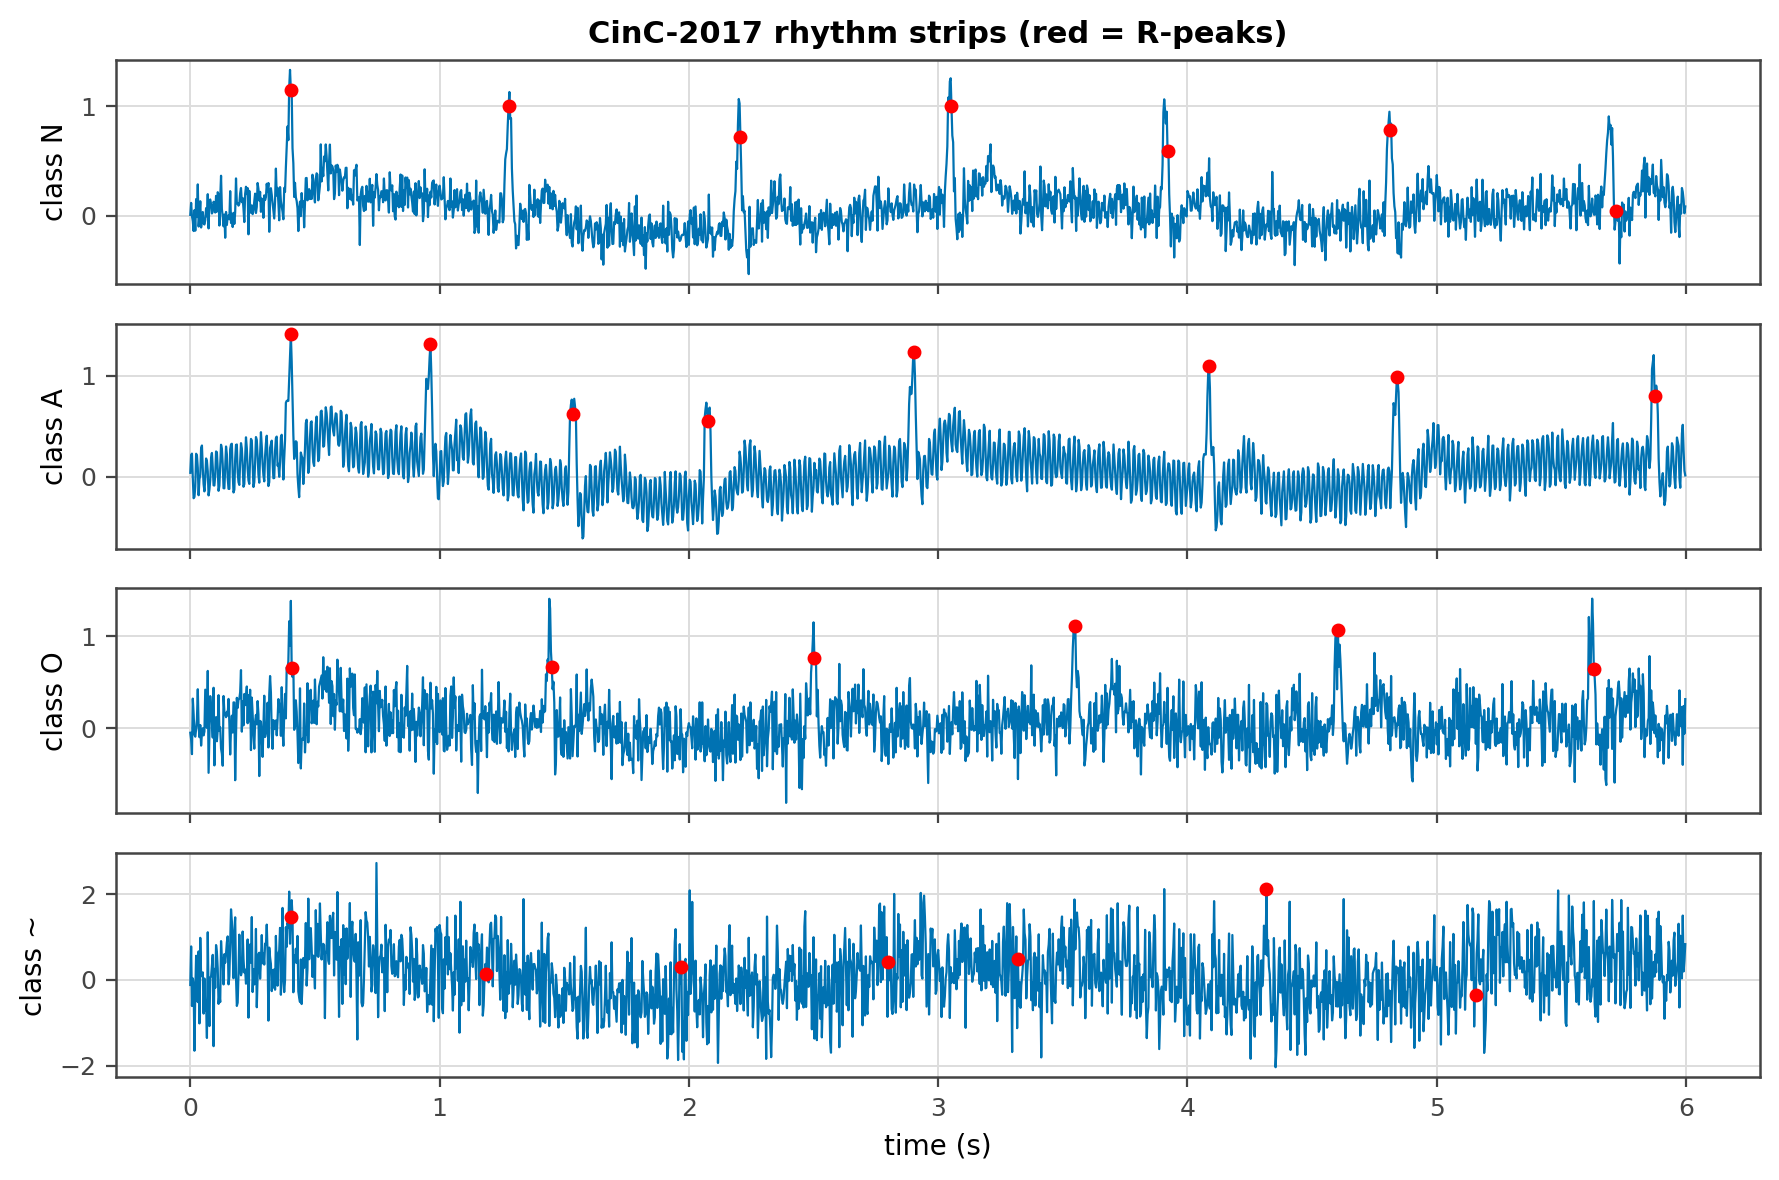

In [3]:
fig, axes = plt.subplots(len(track.meta.classes), 1, figsize=(9, 6), sharex=True)
for ax, cls in zip(axes, track.meta.classes):
    rec = next((r for r in recs if r.labels[0] == cls), None)
    if rec is None: ax.set_visible(False); continue
    x = rec.epochs['ecg'][0]; fs = rec.fs; n = min(len(x), int(6*fs)); t = np.arange(n)/fs
    ax.plot(t, x[:n], lw=0.8); pk = _rpeaks(x, fs); pk = pk[pk < n]
    ax.plot(pk/fs, x[pk], 'r.', ms=8); ax.set_ylabel(f'class {cls}')
axes[-1].set_xlabel('time (s)'); axes[0].set_title('CinC-2017 rhythm strips (red = R-peaks)')
plt.tight_layout(); plt.show()

## 3 · Features + GroupKFold-by-record evaluation

In [4]:
X, y, groups = track.build_dataset(recs)
rep = track.evaluate(X, y, groups)
from sklearn.metrics import recall_score
rc = recall_score(rep['y_true'], rep['y_pred'], labels=rep['labels'], average=None, zero_division=0)
print(f"macro-F1 : {rep['macro_f1']:.3f} | kappa : {rep['cohens_kappa']:.3f} (n_records={rep['n_groups']})")
print('per-class recall:', {c: round(float(v),2) for c,v in zip(rep['labels'], rc)})
print('spread          :', rep['summary'])   # across folds -- one label per record, so per-record spread is undefined

macro-F1 : 0.807 | kappa : 0.716 (n_records=86)
per-class recall: {'N': 0.88, 'A': 0.56, 'O': 0.79, '~': 0.92}
spread          : mean macro_f1 0.777 (sd 0.102, range 0.617-0.881 across 5 folds)


## Read the number against a yardstick

**Yardstick:** CinC-2017 **winners ≈ macro-F1 0.83** (over N/A/O). The synthetic smoke here draws a *typicality* per record — borderline AF that looks almost regular, barely-noisy `~` strips — and uses the challenge's lopsided class counts, so it lands just below the winners' mark rather than above it. On real CinC-2017 data expect well below 0.83, with the gap closed by better QRS/HRV/quality features.

Accuracy hides class imbalance — always read **κ / macro-F1 / the confusion matrix** together, and state the **split unit** with every number.

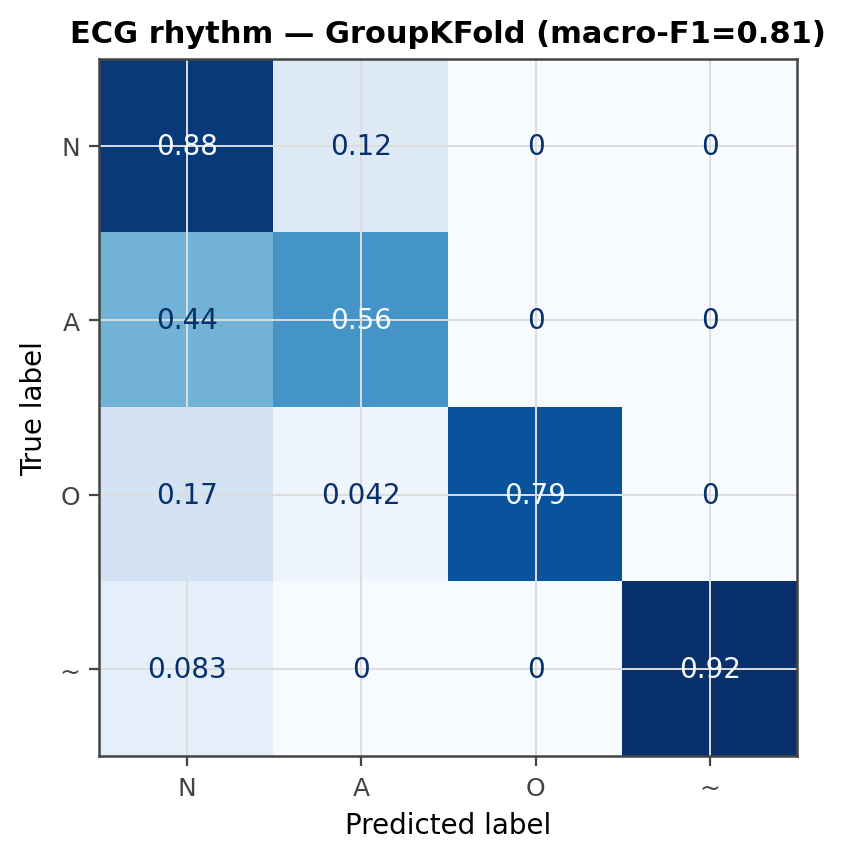

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(5.0, 4.4))
ConfusionMatrixDisplay.from_predictions(rep['y_true'], rep['y_pred'], labels=rep['labels'],
        normalize='true', cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f"ECG rhythm — GroupKFold (macro-F1={rep['macro_f1']:.2f})"); plt.tight_layout(); plt.show()

## Decision points on this track — the menus you are choosing from

Everything below is a **menu, not a recipe.** `tracks/adapter.py` ships options *with their trade-offs* and no blessed answer; picking one, measuring what it cost or earned, and writing down why is the work the rubric grades (criteria 2 and 5). Below, after one warning you should read first, a cell runs a few of them side by side so you can see that the numbers actually move.

Every option listed here is one **this track's adapter actually reads** — the notebook is generated from the track's own `SUPPORTED_CFG_KEYS`, so nothing below is a decoration.

### Stage 2 — preprocessing · `ECGCinC2017Track(cfg={"preprocess": ..., "ecg_band": ..., "notch": ...})`

This track's `preprocess()` is fully wired: `"bandpass"` (with `ecg_band` / `notch`), `"wavelet"`, and `"denoise"` — the Chapter 8 per-noise-type menu below. The plumbing is supplied so it is not the exercise; **the numbers and the justification are yours**, and the trade-offs are real on a dataset whose `~` class *is* the signal-quality class.

| choice | buys you | costs you |
|---|---|---|
| leave the band-pass inside `_rpeaks` (as shipped) | detection owns its own filter; features see the raw signal | the filter is invisible in the report and cannot be swapped as a stage |
| hoist a 0.5–40 Hz band-pass into `preprocess()` | every feature sees the same cleaned signal; the filter becomes reportable | your signal-quality features now measure the *filtered* signal — the `~` class gets harder to spot |
| 50/60 Hz notch | removes mains hum cheaply | your powerline-power feature was **detecting** the hum; notch it away and you delete the evidence |
| baseline-wander high-pass (~0.5 Hz) | stabilises R-peak thresholds | can distort ST morphology if you later add it |
| reject low-SQI records instead of classifying them | higher macro-F1 on what is left | the `~` class *is* the low-SQI class — rejecting it is answering a different question |

### Stage 2, the other way to slice it — **by noise type, not by technique** · `cfg["preprocess"] = "denoise"`

Chapter 8's argument is that you do not choose a filter, you **identify a corruption and then choose its remedy**. §8.11's box is titled *"Identify before you filter"* and closes: *"the noise's signature chooses the tool. Match a narrow, known-frequency artifact to a notch; low-frequency drift to a high-pass; broadband in-band noise to averaging or adaptive filtering; and impulsive outliers to a median — **not the reverse.**"* The epigraph is blunter: *"Removing noise you have not identified is how you accidentally remove signal."*

So `adapter.denoise()` is keyed **one entry per problem**. Run §8.3's three-lens check (time, frequency, what changes across epochs) on a few real epochs first, name what you actually see, then pick a remedy for each:

| Ch. 8 noise type | `cfg` key | options | the trade-off |
|---|---|---|---|
| **Impulsive / electrode pop** (§8.7) | `"impulsive"` | `"median"` | the *only* remedy here that works. §8.7: a linear filter "simply smears the outlier into a blur — **it lets the outlier vote**". A window longer than your narrowest feature flattens that feature |
| **Baseline wander** (§8.8) | `"baseline"` | `"highpass"` · `"detrend"` † · `"wavelet"` † | §8.8: 0.5 Hz is fine for *monitoring*, but a **diagnostic** ECG needs content to 0.05 Hz — too aggressive a corner "can manufacture artificial ST shifts that mimic ischaemia". `"detrend"` avoids the corner and the ringing but happily subtracts a genuine slow physiological trend |
| **Powerline** (§8.6) | `"powerline"` | `"notch"` · `"adaptive"` · `"spectral"` † | §8.6 calls mains "the *friendliest* artifact". `q` is the whole decision: too narrow misses a wandering hum, too wide bites real signal. `"adaptive"` (LMS) tracks drift a fixed notch cannot; `"spectral"` avoids time-domain ringing but needs the frequency resolution to isolate the bins |
| **Broadband / white** (§8.4) | `"broadband"` | `"movavg"` · `"savgol"` · `"wavelet"` · `"gaussian"` | §8.4 is honest that there is no cure: "the only clean weapons against it are averaging and improving the acquisition hardware." `"savgol"` (§9.7) "smooths broadband noise while largely preserving the height, width, and area of peaks"; `"wavelet"` (§10.6) keeps sharp transients best; both still ignore outliers |

**Order is fixed and it is not arbitrary:** `impulsive → baseline → powerline → broadband`. §9.7 is explicit that "impulse removal must precede any linear filtering" — a spike is broadband, so a notch or band-pass cannot delete it, it "only smears the spike across a wide neighbourhood". Pass `broadband="median"` and the harness moves it to the impulsive stage and tells you it did.

> † These three are **extensions beyond the book** — Chapter 8 names only high-pass/detrend, notch, median, and averaging/adaptive. Polynomial and wavelet baseline removal and spectral interpolation are standard practice but are not in the text: use them if you can defend them, and cite something other than the book.

§8.2 asks the prior question too: is this segment *noisy*, or *broken*? "bad segments should be detected and excluded or flagged, **not silently filtered**" — filtering "quietly manufactures a plausible-looking trace out of garbage, and every downstream number inherits the fiction."

### Stage 3 — spectral estimation · `cfg["spectral_method"]`, `cfg["ar_order"]`, `cfg["mt_bandwidth"]`

Every band-power feature is an integral under a **power spectral density** — and the PSD is not a fact you look up, it is an **estimate**. Which estimator produced it is a design decision with the same standing as the band edges (Chapter 7).

§7.2's verdict on the naive option is that the periodogram is **inconsistent**: *"As N grows, we get more frequency bins, but the scatter around the true value at each bin **does not decrease**."* A longer record buys finer bin spacing and no extra reliability. §7.4 then names the law the whole non-parametric family obeys: *"Bartlett's method converts the useless variance of the periodogram into usable smoothness, paid for in resolution. **This resolution-variance trade-off is the governing law of non-parametric spectral estimation.**"*

| `spectral_method` | Type | Variance | Resolution | Best when |
|---|---|---|---|---|
| `"periodogram"` | non-parametric | high (**inconsistent**) | ≈ 1/T | "never for features; a baseline" (§7.16) — run it to be *beaten* |
| `"bartlett"` | non-parametric | ≈ 1/K | ≈ K/T (coarser) | long record, simple averaging; the trade in its purest form |
| `"welch"` *(default)* | non-parametric | ≈ 1/K | tunable via `nperseg` | "long, stationary record — the workhorse" (§7.16) |
| `"multitaper"` | non-parametric | ≈ 1/K, K ≈ 2NW−1 | full-record, set by NW | "short record, want low-leakage smooth PSD (EEG/neuro)" — averages orthogonal Slepian/DPSS tapers over the **whole** record instead of chopping it |
| `"ar"` | **parametric** (Burg) | low, smooth | very high (sub-1/T) | "short segment, resonant rhythm" — a mu peak or an HRV peak you intend to *locate* |

**The AR risk, in §7.9's words:** *"Choose it too low and the spectrum is over-smoothed — real peaks merge or vanish (**under-fitting**). Choose it too high and the model starts fitting noise, sprouting **spurious peaks** that are not in the true spectrum (**over-fitting**)."* At order 40 on the book's EEG epoch the curve "breaks out in a rash of small peaks that are artifacts of over-fitting, not physiology" — and your band powers will faithfully integrate them. Select the order with AIC/MDL, and keep §7.9's rule of thumb (p ≲ N/3, usually far less).

§7.9's decision framework is the sentence to quote in your report: *"if you have a long, stationary record, use non-parametric Welch — the everyday workhorse; if you have a short segment, use parametric AR (Burg or Yule-Walker) for its resolution — and choose the order carefully."* Multitaper sits between: assumption-light like Welch, but often the better non-parametric choice on short segments *"where Welch runs out of segments to average"*.

### Stage 4 — feature selection · `cfg["select"]`, `cfg["select_k"]`, `cfg["select_C"]`

| `select` | Family | Picks features by | Good when | Watch out |
|---|---|---|---|---|
| `"none"` *(default)* | — | keeps everything | few features vs. many samples; you want the model to arbitrate | irrelevant features dilute distance-based learners |
| `"variance"` | filter | dropping near-constant columns | a cheap sanity pass | says nothing about relevance to `y` |
| `"anova"` | filter | univariate F-test vs. the label | fast and stable on tiny folds | blind to feature *interactions* |
| `"mutual_info"` | filter | non-linear dependence with the label | non-monotonic relations | noisier estimate; wants more samples |
| `"tree"` | embedded | forest impurity importance | interactions matter | biased toward continuous/high-cardinality features; **splits credit** between correlated features so near-duplicates survive together |
| `"lasso"` | embedded | L1-penalised linear SVM — coefficients driven to **exactly zero** | you want genuine sparsity and a short, defensible feature list; redundant correlated features should be *eliminated* | assumes roughly **linear** separability; among two correlated features L1 keeps one near-arbitrarily, so **check the surviving set is stable across folds** before calling it "the" feature set |

**`"tree"` vs `"lasso"` is the contrast worth running.** Both are *embedded*, so both see interactions a univariate filter cannot. But on correlated features they behave oppositely: a forest **splits the credit** (two near-duplicate band powers each get half the importance and both survive), while L1 **picks one and zeroes the other** (a second copy of an already-used feature buys no likelihood and costs penalty). `"tree"` gives you a ranking with the redundancy intact; `"lasso"` gives you a genuinely short list. `select_C` is the L1 strength — *smaller C = fewer surviving features* — and it is a number you must report.

**`select_k` is clamped to this track's feature count, out loud.** The default `select_k = 20` is larger than the feature count on four of the six tracks, so a naive first experiment would keep every feature and quietly teach you that selection does nothing. The harness now says so — watch for the `[Track] select=...` line and check `rep["notes"]`. The two **embedded** options ignore `select_k` entirely: how many features survive is a *result*, and the harness prints it.

### Stage 5 — class imbalance · `cfg["imbalance"]`, `cfg["threshold"]`

The supplied baseline uses `class_weight="balanced"`. That is a **default, not a recommendation**, and the rubric grades how you addressed imbalance — so make it a choice you can defend:

| `imbalance` | What it does | Watch out |
|---|---|---|
| `"none"` | plain majority vote | the rare class can be predicted almost never while accuracy still looks fine |
| `"balanced"` *(default)* | per-class weights ∝ 1/frequency | amplifies noisy minority rows too; probabilities stop being calibrated |
| `"balanced_subsample"` | as above, recomputed per tree | forest-specific |
| `"resample"` | random over-sampling **inside `fit`** | duplicated rows invite overfitting — and outside the fold it is a *leak* |
| `"smote"` | **synthetic** minority rows, interpolated between a real sample and one of its k nearest minority neighbours (fold-safe, inside `fit`) | a point halfway between two epochs is a claim about feature space, **not about physiology** — interpolate between two different patients, or an N2 and an N3 epoch, and you have manufactured a body that does not exist. On these small cohorts that risk is live |
| `"adasyn"` | as `"smote"`, concentrated where the minority is hardest to classify | densifies exactly the contested boundary, so mislabelled or artifactual minority rows get amplified most |
| `"threshold"` | move the operating point on the minority class | you must report the threshold; tuning it on test data is as dishonest as a leak |

**The distinction to state in your report:** `"balanced"` never adds a row, it changes how much each existing row *counts*. `"resample"` adds exact copies, so the minority region gets heavier but not one millimetre wider. `"smote"` adds **new points in feature space**, so the region genuinely expands and the boundary is pushed rather than weighted — which is the whole benefit and the whole danger. If you use it, say what a synthetic minority sample *means* on your track, and be honest if the answer is "nothing physiological".

Doing nothing is a defensible answer *if you say you looked and why you left it*. A silent default is worth no marks.

> **Two things the wrapper does for you, and both are worth understanding.** `"resample"`, `"smote"` and `"adasyn"` are all applied **inside `fit`**, so they are redone per fold on training rows only — resampling before the split puts copies (or interpolations) of the test rows into the training set and the score becomes fiction. And SMOTE/ADASYN run **after** the pipeline's `StandardScaler` (`scale → resample → clf`), because "k nearest minority neighbours" is a statement about *distance*: search in raw units and whichever feature happens to be measured in the largest numbers picks the neighbours, regardless of physiological similarity. In Colab the setup cell installs `imbalanced-learn` for you; every other option on this menu is sklearn-only.

### Read downstream symptoms **backwards**, to the stage that caused them

The reflex when a number disappoints is to retune the classifier (stage 5). It is usually the wrong stage. Diagnose upwards:

| What the report shows | The tempting fix | Where the cause usually is |
|---|---|---|
| **Worst-subject metric far below the mean** (check `rep['summary']` and `rep['spread_rows']`) | more trees, deeper trees | **Stage 2 — preprocessing.** A per-recording normalisation, a different band, or artifact handling. A feature that means different things in different subjects cannot be rescued by a classifier. Then **stage 4**: a selector fit on a majority of easy subjects can drop the only feature the hard one needed. |
| **Good pooled metric, one class near-zero recall** | accept it; the average looks fine | **Stage 5 — imbalance handling** first (the menu above), then **stage 3**: if no feature actually describes that class, no weighting invents one. |
| **Feature selection changed nothing at all** | conclude selection is useless here | **`select_k` ≥ your feature count** — the harness prints a note saying exactly this. Lower `select_k` before drawing any conclusion. |
| **A leaky split scores far above the honest one** | quietly report the higher number | **Validation, stage 1.** The split unit is the deployment claim. This gap is the size of the lie. |
| **Train ≫ test, and the spread across groups is huge** | regularise the model | **Stage 3 — feature extraction.** Too many features for the number of *independent groups* (not rows). Fewer, better-motivated features beat more regularisation. |

> **Log it.** Copy [`tracks/results_log_TEMPLATE.md`](https://github.com/farhad-abtahi/CM2013/blob/main/tracks/results_log_TEMPLATE.md) into your team repo as `RESULTS.md` and add a row per iteration *plus* a decision-log row per choice above. Rubric **Criterion 9 — Iteration & revision history** is graded from that file, and it specifically asks for at least one decision you went back and **revised because of a downstream result** — not just more iterations forward.

### ⚠️ Read this **before** you run the next cell

**Comparing many options against the same folds is itself a way to overfit.** The cell below scores several design choices on the *same* group-aware folds — and those are the same folds that will produce the number you report. No individual run leaks a subject; the harness guarantees that. But if you try twelve configurations against one held-out set and then report the best, the winner is chosen partly because it suits *these particular subjects*, and its margin over the runner-up is optimistically biased. This is the **garden of forking paths**: the leak is not in any one fold, it is in the *selection* you perform across many of them. It gets worse the more you look, and it is invisible — the report comes out looking exactly like an honest one.

Which is why this warning is here rather than under the results: the decisions that fix it can only be made **before you know which option won**. Take one minute now and write down:

1. **How many configurations you will compare** — a handful, not a sweep. Put the list in `RESULTS.md` *before* you run it, and report the count in your report.
2. **Whether you are holding out a DEV set** — a few groups set aside up front, so the comparison and the final number do not come from the same folds.
3. **What you will count as a difference** — a margin smaller than the spread across subjects (the `worst / best` columns the cell prints) is *no difference*, not a win.

The trade-offs of those two approaches are laid out in full just after the cell. Read them now if you want the argument first; the point is that the choice between them is only honest while you still cannot see the table.

In [6]:
# A/B the SAME honest harness under different design choices. None of these is
# "the answer" -- the point is that the numbers MOVE, so the choice is a real one
# with a consequence you can measure and defend.
X, y, groups = track.build_dataset(recs)
PRIMARY = track.meta.default_metrics[0]

options = [
    ('supplied baseline', {}),
    ('select=anova, default k=20', {'select': 'anova'}),
    ('select=anova, k=6', {'select': 'anova', 'select_k': 6}),
    ('select=mutual_info, k=6', {'select': 'mutual_info', 'select_k': 6}),
    ('select=lasso (L1, C=1.0)', {'select': 'lasso'}),
    ('imbalance=none', {'imbalance': 'none'}),
    ('imbalance=resample', {'imbalance': 'resample'}),
    ('imbalance=smote', {'imbalance': 'smote'}),
    ('preprocess: band-pass 0.5-40 + notch', {'preprocess': 'bandpass', 'notch': 50.0, 'rebuild': True}),
    ('preprocess: wavelet denoise (db4)', {'preprocess': 'wavelet', 'rebuild': True}),
    ('preprocess: by noise type (Ch.8)', {'preprocess': 'denoise', 'impulsive': 'median', 'baseline': 'highpass', 'powerline': 'notch', 'rebuild': True}),
    ('spectral: multitaper band power', {'spectral_method': 'multitaper', 'rebuild': True}),
]
rows, unit = [], None
for name, c in options:
    c = dict(c)
    # a PREPROCESSING choice changes the features themselves, so stages 2-3 must
    # re-run; a selection/imbalance choice only changes stages 4-5 inside the folds.
    if c.pop("rebuild", False):
        Xc, yc, gc = track.build_dataset(recs, cfg=c)
    else:
        Xc, yc, gc = X, y, groups
    r = track.evaluate(Xc, yc, gc, cfg=c)
    sp = r["spread"].get(PRIMARY, {})
    unit = r["spread_unit"]      # subject / record / fold -- whichever the metric is defined on
    rows.append((name, r[PRIMARY], sp.get("min", float("nan")), sp.get("max", float("nan"))))

print(f"\n{'design choice':<38} {PRIMARY:>12}   worst / best {unit}")
print("-" * 82)
for name, val, lo, hi in rows:
    print(f"{name:<38} {val:>12.3f}   {lo:.3f} / {hi:.3f}")

print("\nHarness notes (things it refuses to hide):")
for n in track.notes or ["(none)"]:
    print("  *", n)

[ECGCinC2017Track] select='anova': select_k=20 >= n_features=11, so k was reduced to 11 and EVERY feature is kept — feature selection is a NO-OP at this k on this track. Lower select_k (try 5) if you want this stage to actually choose.
[ECGCinC2017Track] select='anova': keeping 6 of 11 features (5 dropped per training fold).
[ECGCinC2017Track] select='mutual_info': keeping 6 of 11 features (5 dropped per training fold).
[ECGCinC2017Track] select='lasso' (C=1.0): L1 kept 11 of 11 features with a non-zero coefficient (0 zeroed per training fold). Re-fit on another fold the surviving set may differ — L1 picks ONE of each correlated pair, so check the stability before calling this 'the' feature set.

design choice                              macro_f1   worst / best fold
----------------------------------------------------------------------------------
supplied baseline                             0.807   0.617 / 0.881
select=anova, default k=20                    0.807   0.617 / 0.881
sel

Note what the imbalance rows do *not* do here: on four classes with a dominant Normal, re-weighting moves macro-F1 only slightly, because the binding constraint is that no feature cleanly separates borderline AF from a normal strip with ectopics. That is a **stage-3 problem, not a stage-5 one** — and it is the honest answer to give in the report. Per-class recall, not the macro average, is what tells you this; keep printing it.

### Now you have the table — two things it does *not* protect you from

**1 · The forking-paths problem you were warned about, in full.**
Every row in that table was scored on the *same* group-aware folds — and those are the same folds that will produce the number you report. A dozen comparisons on a cohort of five subjects is a lot of selection pressure on very little data.

Two defensible ways to handle it, either of which is worth marks if you say which you used:

| approach | what you do | what it costs |
|---|---|---|
| **a separate development set** | hold out a few groups *up front* as a DEV set, compare every design option on DEV only, then run the winner **once** on the untouched evaluation folds and report that number | fewer groups for both purposes — painful on the small cohorts here, and the DEV estimate is noisy |
| **a comparison budget** | decide in advance how many configurations you will compare (a handful, not a sweep), write them into `RESULTS.md` *before* you run them, and report the count | you may miss a better option; you must resist re-opening the budget after seeing the numbers, which is the whole discipline |

Whichever you choose, **report the number of configurations you compared**, and read a small margin (a couple of points, inside the per-group spread) as *no difference* rather than as a win. A difference smaller than the spread across subjects is not a result. If you have just run the cell above without deciding any of this first, the honest move is to write down the count you have already spent and adopt a budget from here on — not to keep comparing until something wins.

**2 · Features here are built BEFORE the folds are cut — which is safe only because nothing learns.** `build_dataset()` runs stages 2-3 over every recording once, and `evaluate()` splits afterwards. Every preprocessing option on the menus above is **stateless** (a fixed filter, or a threshold estimated from one epoch's own samples), so computing it before or inside the fold gives identical features and the ordering is purely a speed decision.

That stops being true the moment you add a stage that **learns from the data** — a **CSP** spatial filter, a PCA/ICA basis, a z-score whose mean and scale come from the pooled cohort, a learned artifact template. Fit any of those over all the recordings first and every held-out subject has already shaped the transform that built the training features. **The harness will not catch this**: `assert_no_subject_leak` checks group ids per fold, and it cannot see that a filter was learned from them, so the number comes out clean and wrong. A learned stage must be fit *inside* the fold — as a step in the `clf=` pipeline (cloned and refit per fold) or via `select_features()` — and you should say in `RESULTS.md` which you did.

### ⚠️ The one thing above that is **not** a menu — see the leak once

Every table above is a genuine choice you get to make and defend. **The validation scheme is not one.** The leakage-safe split — LOSO or GroupKFold on this track's declared split unit — is the only number that counts for your grade, and `TrackAdapter.evaluate()` enforces it on every fold with `assert_no_subject_leak`. There is no config key to turn it off, deliberately.

So why run the wrong one at all? Because **seeing the gap once is the fastest way to understand why.** The cell below scores this track's data twice: once with a naive random stratified 5-fold split that ignores the leakage unit entirely, and once with the honest group-aware split. Same features, same classifier, same metric. The only difference is *who is allowed to appear on both sides of the split* — and the difference between the two numbers is the size of the claim you would be making falsely.

Predict the gap before you run it.

In [7]:
# NOT A CHOICE. The honest split is the only one that counts for your grade --
# but seeing the gap once is the fastest way to understand why.
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from adapter import metrics_for

PRIMARY = track.meta.default_metrics[0]
X, y, groups = track.build_dataset(recs)          # rebuilt so this cell stands alone

# 1) THE LEAKY SPLIT -- random/stratified, blind to the leakage unit. Rows from the
#    same subject/record land on BOTH sides, so the model can recognise the person
#    instead of the phenomenon.
leaky_pred = cross_val_predict(track.baseline(), X, y,
                               cv=StratifiedKFold(5, shuffle=True, random_state=0))
leaky = metrics_for(y, leaky_pred)[PRIMARY]

# 2) THE HONEST SPLIT -- the scaffold's own group-aware LOSO / GroupKFold.
honest = track.evaluate(X, y, groups)[PRIMARY]

unit = track.meta.split_unit
rows_per_group = np.bincount(np.unique(groups, return_inverse=True)[1])
gap = leaky - honest
print(f"leaky  random 5-fold split      : {PRIMARY} = {leaky:.3f}   <-- NOT a deployment claim")
print(f"honest {unit + '-wise split':<24} : {PRIMARY} = {honest:.3f}   <-- the number that counts")
print(f"{'gap (the size of the lie)':<32} : {gap:+.3f}")
print(f"{'rows per ' + unit:<32} : max {rows_per_group.max()}, median {int(np.median(rows_per_group))}")
print()

if rows_per_group.max() == 1:
    print(f"READ IT HONESTLY: on this track every {unit} contributes exactly ONE row, so a random")
    print(f"  split CANNOT put the same {unit} on both sides. There is structurally nothing to")
    print( "  leak here, and the gap is expected to be ~0 (what you see is just fold-composition")
    print( "  noise, and it can even come out negative). This is not evidence that leakage is a")
    print( "  non-issue in biosignals -- it is this track's granularity making it impossible.")
    print(f"  The tracks with many epochs per {unit} are where the gap opens up; go look at one.")
elif gap >= 0.05:
    print(f"READ IT HONESTLY: each {unit} contributes up to {rows_per_group.max()} rows, so a random split")
    print(f"  scatters one {unit}'s rows across train AND test. The model scores partly by")
    print(f"  recognising the {unit} -- which at deployment is a {unit} it has never seen.")
    print(f"  That {gap:+.3f} is the size of the claim you would be making falsely.")
else:
    print(f"READ IT HONESTLY -- and this is the interesting case. Each {unit} contributes up to")
    print(f"  {rows_per_group.max()} rows, so a leak WAS structurally possible, and yet the gap is only {gap:+.3f}.")
    print( "  The tempting conclusion ('leakage does not matter here') is the wrong one. What a")
    print(f"  near-zero gap actually says is that the current features carry little {unit}-specific")
    print( "  structure for the model to memorise -- which, when the honest score is also close to")
    print( "  chance, usually means they are not carrying much of ANYTHING yet.")
    print( "  So this is a statement about your feature set, not a licence to split randomly.")
    print( "  RE-RUN THIS CELL after you improve stage 2/3 (e.g. a CSP spatial filter, per-subject")
    print( "  normalisation): the better your features get at describing the individual, the wider")
    print( "  this gap will open -- which is exactly when an honest split starts to matter most.")
print()
print("Rule: the split unit IS the deployment claim. State it with every number you report.")

leaky  random 5-fold split      : macro_f1 = 0.769   <-- NOT a deployment claim
honest record-wise split        : macro_f1 = 0.807   <-- the number that counts
gap (the size of the lie)        : -0.038
rows per record                  : max 1, median 1

READ IT HONESTLY: on this track every record contributes exactly ONE row, so a random
  split CANNOT put the same record on both sides. There is structurally nothing to
  leak here, and the gap is expected to be ~0 (what you see is just fold-composition
  noise, and it can even come out negative). This is not evidence that leakage is a
  non-issue in biosignals -- it is this track's granularity making it impossible.
  The tracks with many epochs per record are where the gap opens up; go look at one.

Rule: the split unit IS the deployment claim. State it with every number you report.


**Whatever gap you just measured, the honest number is the one that goes in your report** — and rubric **Criterion 8** exists to catch a report that quotes the flattering one.

Read the printed diagnosis rather than just the number, because a near-zero gap means two very different things depending on the track:

| what you see | what it means |
|---|---|
| **a large positive gap** (sleep, HAR, EMG — the epoch-per-subject tracks) | the leak is real and you just measured it. On EMG it is the largest in the scaffold, because overlapping windows from one contraction are nearly copies of each other |
| **~zero gap, one row per group** (ECG, CTG — record-level tracks) | structurally impossible to leak: each record contributes a single row, so no record can straddle the split. A fact about granularity, **not** a licence to split randomly on your next dataset |
| **~zero gap, many rows per group** (BCI) | the honest-looking case that is actually a warning. A leak *was* possible and did not happen, which means the features currently carry little subject-specific structure — and with a score near chance, not much of anything else either. **Re-run the cell after you add CSP or per-subject normalisation**: as the features get better at describing the individual, this gap opens up, which is precisely when the honest split starts to matter most |

Two things worth writing down in `RESULTS.md` while you have the numbers in front of you: what you *predicted* the gap would be, and which real-world claim the leaky number would have been. "93 % accurate at detecting this condition" and "93 % accurate **on people it has already seen**" are different sentences, and only one of them is a product.

## 4 · Hold-out submission (`record,label`)

In [8]:
import tempfile
recs = list(np.random.default_rng(0).permutation(recs))  # smoke() groups records by
                                                          # class in order -- shuffle
                                                          # before an index-based split
split = int(0.8*len(recs)); model = track.train_baseline(recs[:split])
out = os.path.join(tempfile.gettempdir(), 'ecg_predictions.csv')
track.write_submission(recs[split:], out, model)
print(open(out).read().splitlines()[:6])

['record,label', 'R0058,O', 'R0014,N', 'R0038,N', 'R0075,~', 'R0031,N']


## Reflect & improve

1. **Was your prediction right?** If the real number surprised you, *why*?
2. **Answer the guiding questions above** in your report — that is how you *motivate* your design (L5), not just implement it.
3. **Improve the supplied baseline honestly**: better preprocessing and **feature construction** first (the DSP is the point), then a better model — validated *inside* the folds, keeping the declared split unit. Read your gain against the yardstick.
4. **Go back, don't only go forward.** At least one decision above should end up *revised* because of a number further downstream — that is the loop the capstone is actually about, and rubric **Criterion 9** grades it from your `RESULTS.md` ([`tracks/results_log_TEMPLATE.md`](https://github.com/farhad-abtahi/CM2013/blob/main/tracks/results_log_TEMPLATE.md)). Log the iteration *and* the decision that changed.
5. **Submit** the `predictions.csv` below for hold-out evaluation (`tracks/HOLDOUT_EVALUATION.md`).

---
*Real-data capstone companion for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic path is reproducible and offline; the real path is an opt-in, agreement-free public dataset. Numbers are honest, not clinical benchmarks. Generated by `tools/build_track_notebooks.py`.*